In [1]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [3]:

breast_cancer = fetch_ucirepo(id=17)

X = breast_cancer.data.features
y = breast_cancer.data.targets

y = y.iloc[:, 0]

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

print("\nFirst 5 rows:")
display(X.head())

print("\nTarget values:")
print(y.head())

Dataset shape: (569, 30)
Target shape: (569,)

First 5 rows:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target values:
0    M
1    M
2    M
3    M
4    M
Name: Diagnosis, dtype: object


In [4]:
# Encode target labels
y = y.map({
    'B': 0,
    'M': 1
})

print(y.value_counts())

Diagnosis
0    357
1    212
Name: count, dtype: int64


In [5]:
print("0 = Benign")
print("1 = Malignant")

0 = Benign
1 = Malignant


In [6]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nFeature names:")
print(list(X.columns))

print("\nMissing values:")
print(X.isnull().sum().sum())

print("\nDataset information:")
print(X.info())

Number of samples: 569
Number of features: 30

Feature names:
['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']

Missing values:
0

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactn

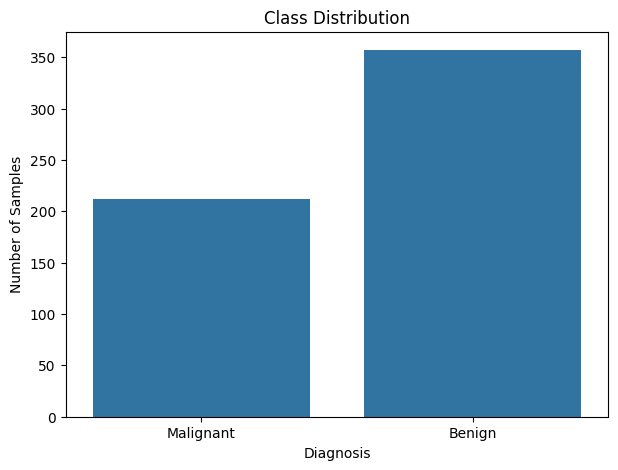

In [7]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y.map({
        0: 'Benign',
        1: 'Malignant'
    })
)

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.savefig("figures5/class_distribution.png", dpi=600, bbox_inches="tight")
plt.show()

In [8]:
class_counts = y.value_counts().sort_index()

print("Benign samples:", class_counts[0])
print("Malignant samples:", class_counts[1])

Benign samples: 357
Malignant samples: 212


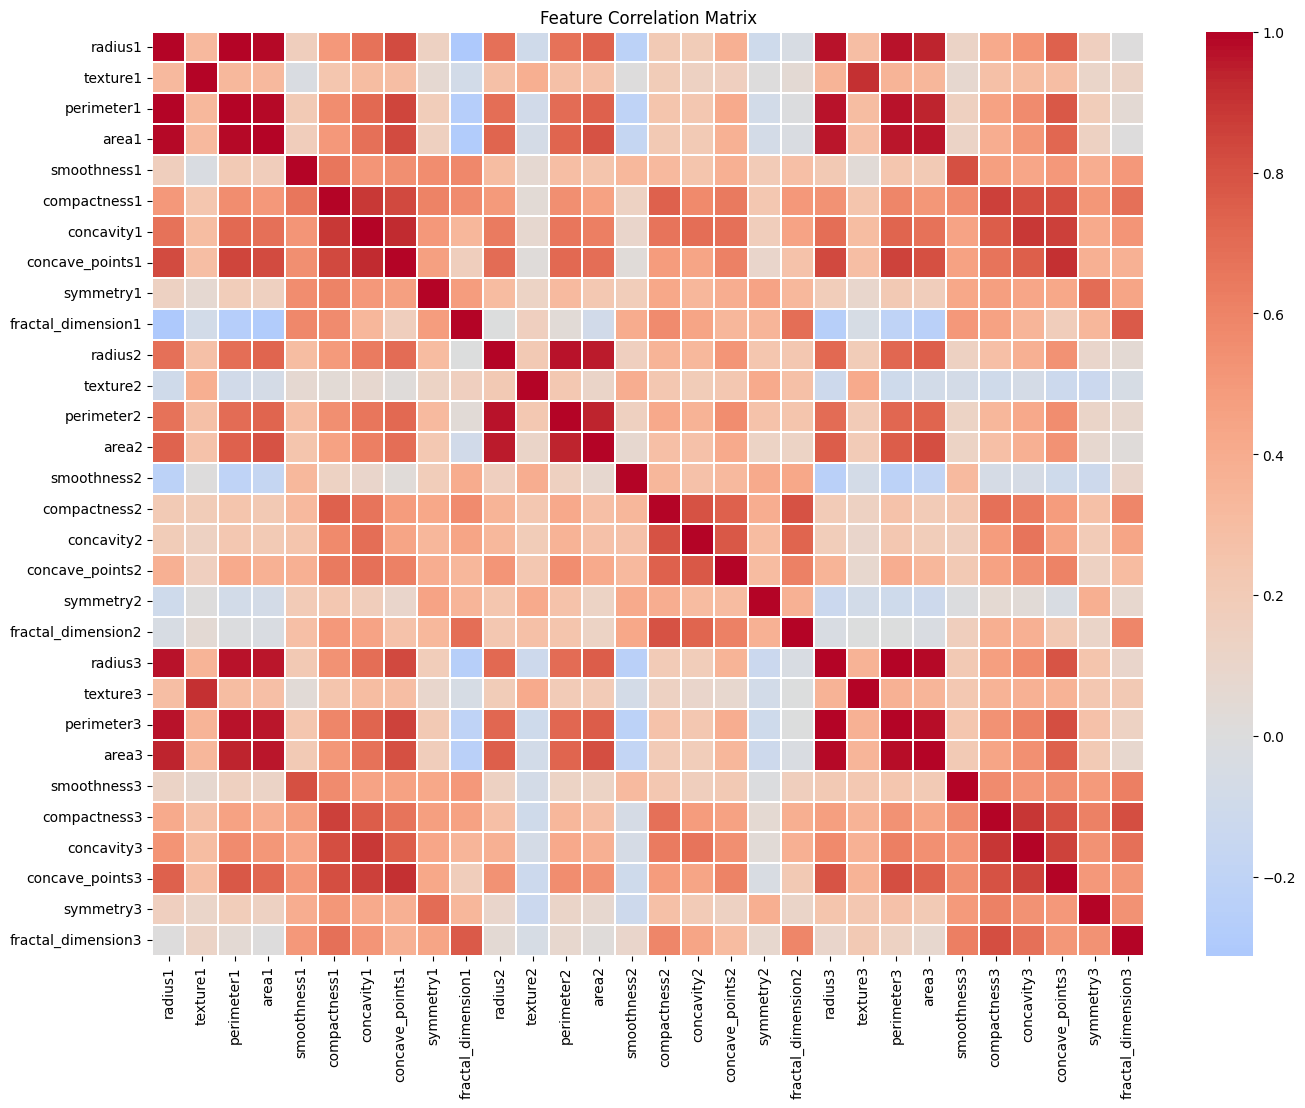

In [9]:
plt.figure(figsize=(16, 12))

correlation_matrix = X.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Feature Correlation Matrix")
plt.savefig("figures5/feature_correlation.png", dpi=600, bbox_inches="tight")
plt.show()

In [10]:
target_corr = X.copy()
target_corr["Diagnosis"] = y

target_correlations = (
    target_corr.corr()["Diagnosis"]
    .drop("Diagnosis")
    .sort_values(key=abs, ascending=False)
)

print(target_correlations)

concave_points3       0.793566
perimeter3            0.782914
concave_points1       0.776614
radius3               0.776454
perimeter1            0.742636
area3                 0.733825
radius1               0.730029
area1                 0.708984
concavity1            0.696360
concavity3            0.659610
compactness1          0.596534
compactness3          0.590998
radius2               0.567134
perimeter2            0.556141
area2                 0.548236
texture3              0.456903
smoothness3           0.421465
symmetry3             0.416294
texture1              0.415185
concave_points2       0.408042
smoothness1           0.358560
symmetry1             0.330499
fractal_dimension3    0.323872
compactness2          0.292999
concavity2            0.253730
fractal_dimension2    0.077972
smoothness2          -0.067016
fractal_dimension1   -0.012838
texture2             -0.008303
symmetry2            -0.006522
Name: Diagnosis, dtype: float64


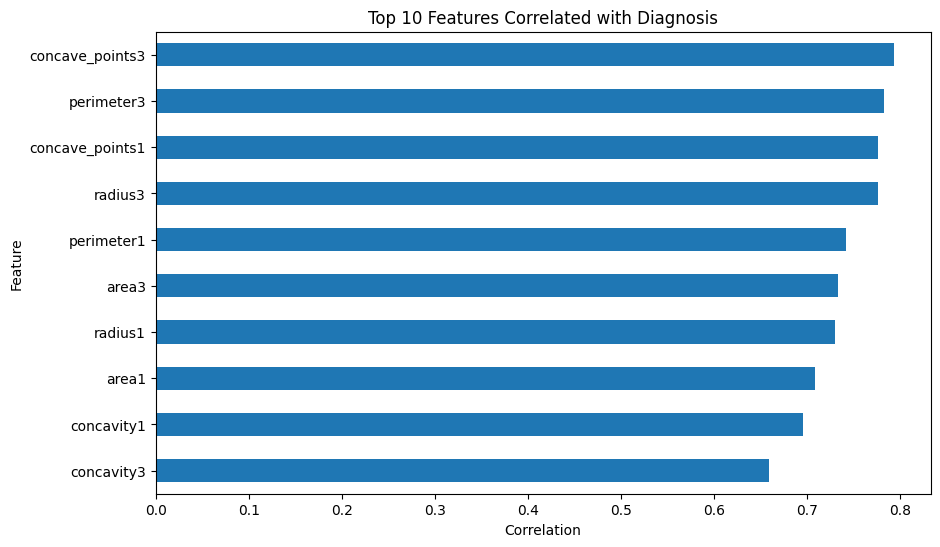

In [11]:
plt.figure(figsize=(10, 6))

target_correlations.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Features Correlated with Diagnosis")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.savefig("figures5/top_correlated_features.png", dpi=600, bbox_inches="tight")
plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
# decision trees do not require feature scaling as the order is maintained which is what is important
dt_baseline = DecisionTreeClassifier(
    random_state=42
)

dt_baseline.fit(X_train, y_train)

y_pred_dt_baseline = dt_baseline.predict(X_test)

print("Baseline Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt_baseline))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_dt_baseline,
        target_names=["Benign", "Malignant"]
    )
)

Baseline Decision Tree Accuracy: 0.9298245614035088

Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      0.94      0.94        72
   Malignant       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [ ]:
dt_param_grid = {
    "criterion" : ["gini", "entropy"],
    "max_depth" : [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split" : [2, 5, 10], # minimum number of samples required in the node before it can be split
    "min_samples_leaf" : [1, 2, 4] # minimum number of samples in the leaf node
}

In [16]:
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)

dt_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

In [17]:
print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

print("\nBest 5-Fold CV F1 Score:")
print(dt_grid.best_score_)

Best Decision Tree Parameters:
{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}

Best 5-Fold CV F1 Score:
0.9163028549720931


In [18]:
dt_results = pd.DataFrame(dt_grid.cv_results_)

dt_results = dt_results.sort_values(
    by="mean_test_score",
    ascending=False
)

display(
    dt_results[
        [
            "param_criterion",
            "param_max_depth",
            "param_min_samples_split",
            "param_min_samples_leaf",
            "mean_test_score",
            "std_test_score"
        ]
    ].head(20)
)

,param_criterion,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score,std_test_score
93,entropy,4,2,2,0.916303,0.034097
94,entropy,4,5,2,0.916303,0.034097
90,entropy,4,2,1,0.914479,0.025547
95,entropy,4,10,2,0.914191,0.026295
104,entropy,5,10,2,0.912127,0.034256
91,entropy,4,5,1,0.910777,0.032087
122,entropy,8,10,2,0.909411,0.034930
113,entropy,6,10,2,0.909411,0.034930
131,entropy,10,10,2,0.909411,0.034930
140,entropy,None,10,2,0.909411,0.034930


In [19]:
dt_table1 = dt_results[
    [
        "param_criterion",
        "param_max_depth",
        "mean_test_score"
    ]
].copy()

dt_table1.columns = [
    "Criterion",
    "Max Depth",
    "Avg CV F1 Score"
]

# Calculate accuracy separately for every combination
dt_accuracy_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

dt_accuracy_grid.fit(X_train, y_train)

dt_accuracy_results = pd.DataFrame(
    dt_accuracy_grid.cv_results_
)

dt_table1["Avg CV Accuracy (%)"] = (
    dt_accuracy_results.loc[
        dt_table1.index,
        "mean_test_score"
    ].values * 100
)

dt_table1["Avg CV F1 Score"] = (
    dt_table1["Avg CV F1 Score"]
)

dt_table1 = dt_table1[
    [
        "Criterion",
        "Max Depth",
        "Avg CV Accuracy (%)",
        "Avg CV F1 Score"
    ]
]

display(dt_table1.head(20))

,Criterion,Max Depth,Avg CV Accuracy (%),Avg CV F1 Score
93,entropy,4,94.065934,0.916303
94,entropy,4,94.065934,0.916303
90,entropy,4,93.846154,0.914479
95,entropy,4,93.846154,0.914191
104,entropy,5,93.626374,0.912127
91,entropy,4,93.626374,0.910777
122,entropy,8,93.406593,0.909411
113,entropy,6,93.406593,0.909411
131,entropy,10,93.406593,0.909411
140,entropy,None,93.406593,0.909411


In [20]:
best_dt = dt_grid.best_estimator_

best_dt.fit(X_train, y_train)

y_pred_dt = best_dt.predict(X_test)
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]

In [21]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_precision = precision_score(
    y_test,
    y_pred_dt
)

dt_recall = recall_score(
    y_test,
    y_pred_dt
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt
)

dt_auc = roc_auc_score(
    y_test,
    y_prob_dt
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("AUC      :", dt_auc)

Decision Tree Results
---------------------
Accuracy : 0.9298245614035088
Precision: 1.0
Recall   : 0.8095238095238095
F1 Score : 0.8947368421052632
AUC      : 0.9563492063492064


In [22]:
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.90      1.00      0.95        72
   Malignant       1.00      0.81      0.89        42

    accuracy                           0.93       114
   macro avg       0.95      0.90      0.92       114
weighted avg       0.94      0.93      0.93       114



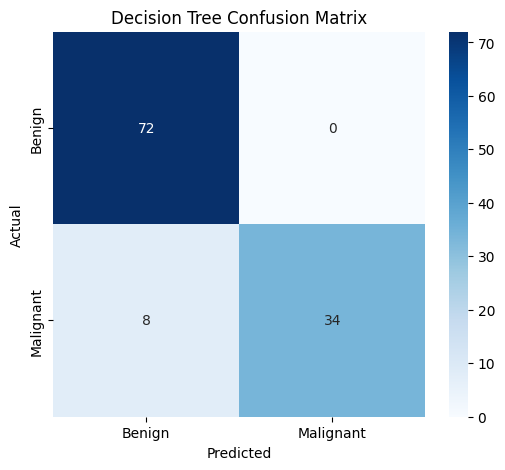

In [23]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("figures5/dt_confusion_matrix.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
rf_param_grid = {
    "n_estimators": [50, 100, 200],

    "max_depth": [3, 5, 8, 10, None],

    "max_features": ["sqrt", "log2", None], # no of features considered for best split 

    "bootstrap": [True, False] # random sampling with replacement
}

In [25]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_grid=rf_param_grid,

    cv=cv,

    scoring="f1",

    n_jobs=-1,

    return_train_score=True
)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True, False], 'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation t

In [26]:
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest 5-Fold CV F1 Score:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 50}

Best 5-Fold CV F1 Score:
0.9617018240249908


In [27]:
rf_results = pd.DataFrame(
    rf_grid.cv_results_
)

rf_results = rf_results.sort_values(
    by="mean_test_score",
    ascending=False
)

display(
    rf_results[
        [
            "param_n_estimators",
            "param_max_depth",
            "param_max_features",
            "param_bootstrap",
            "mean_test_score",
            "std_test_score"
        ]
    ].head(20)
)

,param_n_estimators,param_max_depth,param_max_features,param_bootstrap,mean_test_score,std_test_score
72,50,10,sqrt,False,0.961702,0.014626
74,200,10,sqrt,False,0.961529,0.015538
83,200,None,sqrt,False,0.961529,0.015538
56,200,5,sqrt,False,0.960813,0.028374
81,50,None,sqrt,False,0.958886,0.010564
76,100,10,log2,False,0.958469,0.023854
75,50,10,log2,False,0.958374,0.014965
84,50,None,log2,False,0.958374,0.014965
55,100,5,sqrt,False,0.958016,0.032365
32,200,10,log2,True,0.955720,0.013224


In [28]:
rf_table2 = rf_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_max_features",
        "param_bootstrap",
        "mean_test_score"
    ]
].copy()

rf_table2.columns = [
    "n estimators",
    "Max Depth",
    "Max Features",
    "Bootstrap",
    "Avg CV F1 Score"
]

rf_table2["Avg CV Accuracy (%)"] = 0.0

rf_table2 = rf_table2[
    [
        "n estimators",
        "Max Depth",
        "Max Features",
        "Bootstrap",
        "Avg CV Accuracy (%)",
        "Avg CV F1 Score"
    ]
]

display(rf_table2.head(20))

,n estimators,Max Depth,Max Features,Bootstrap,Avg CV Accuracy (%),Avg CV F1 Score
72,50,10,sqrt,False,0.0,0.961702
74,200,10,sqrt,False,0.0,0.961529
83,200,None,sqrt,False,0.0,0.961529
56,200,5,sqrt,False,0.0,0.960813
81,50,None,sqrt,False,0.0,0.958886
76,100,10,log2,False,0.0,0.958469
75,50,10,log2,False,0.0,0.958374
84,50,None,log2,False,0.0,0.958374
55,100,5,sqrt,False,0.0,0.958016
32,200,10,log2,True,0.0,0.955720


In [29]:
best_rf = rf_grid.best_estimator_

best_rf.fit(
    X_train,
    y_train
)

y_pred_rf = best_rf.predict(X_test)

y_prob_rf = best_rf.predict_proba(
    X_test
)[:, 1]

In [30]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("AUC      :", rf_auc)

Random Forest Results
---------------------
Accuracy : 0.9649122807017544
Precision: 1.0
Recall   : 0.9047619047619048
F1 Score : 0.95
AUC      : 0.9950396825396826


In [31]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



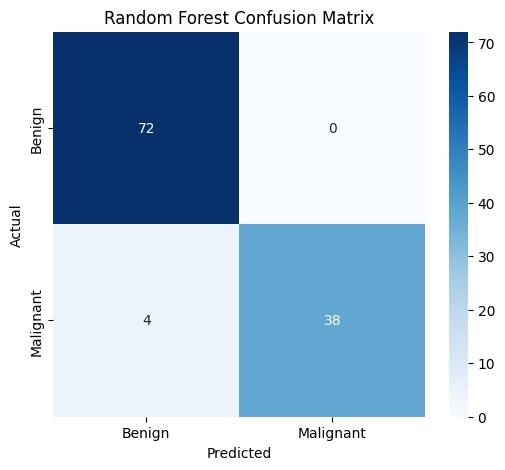

In [32]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("figures5/rf_confusion_matrix.png", dpi=600, bbox_inches="tight")
plt.show()

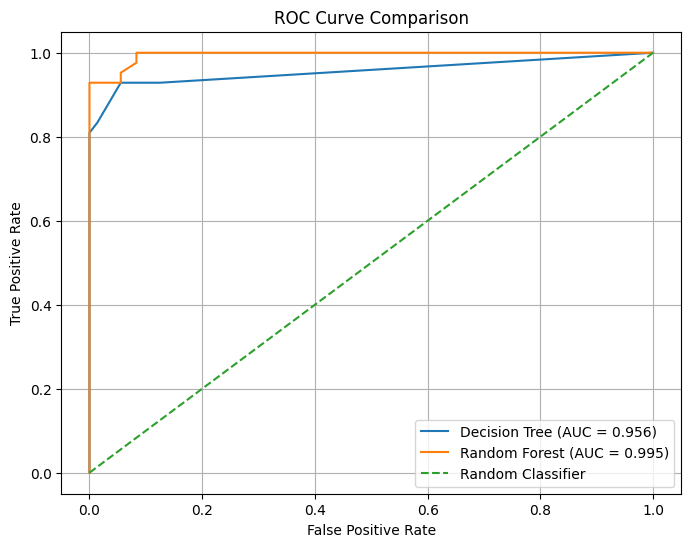

In [33]:
# Decision Tree ROC
fpr_dt, tpr_dt, _ = roc_curve(
    y_test,
    y_prob_dt
)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {dt_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid()

plt.savefig("figures5/roc_curve.png", dpi=600, bbox_inches="tight")
plt.show()

In [34]:
# Best Decision Tree CV scores
dt_fold_scores = cross_val_score(
    best_dt,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

# Best Random Forest CV scores
rf_fold_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

In [35]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],

    "Fold 1": [
        dt_fold_scores[0],
        rf_fold_scores[0]
    ],

    "Fold 2": [
        dt_fold_scores[1],
        rf_fold_scores[1]
    ],

    "Fold 3": [
        dt_fold_scores[2],
        rf_fold_scores[2]
    ],

    "Fold 4": [
        dt_fold_scores[3],
        rf_fold_scores[3]
    ],

    "Fold 5": [
        dt_fold_scores[4],
        rf_fold_scores[4]
    ],

    "Average": [
        dt_fold_scores.mean(),
        rf_fold_scores.mean()
    ]
})

display(cv_comparison)

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Decision Tree,0.934066,0.956044,0.901099,0.956044,0.956044,0.940659
1,Random Forest,0.967033,0.989011,0.967033,0.956044,0.978022,0.971429


In [36]:
cv_comparison_percentage = cv_comparison.copy()

for column in cv_comparison_percentage.columns[1:]:
    cv_comparison_percentage[column] *= 100

display(cv_comparison_percentage.round(2))

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Decision Tree,93.41,95.6,90.11,95.6,95.6,94.07
1,Random Forest,96.70,98.9,96.70,95.6,97.8,97.14


In [37]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ],

    "Decision Tree": [
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1,
        dt_auc
    ],

    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]
})

display(comparison.round(4))

,Metric,Decision Tree,Random Forest
0,Accuracy,0.9298,0.9649
1,Precision,1.0000,1.0000
2,Recall,0.8095,0.9048
3,F1 Score,0.8947,0.9500
4,AUC,0.9563,0.9950


In [38]:
comparison_percentage = comparison.copy()

comparison_percentage.loc[
    comparison_percentage["Metric"] != "AUC",
    ["Decision Tree", "Random Forest"]
] *= 100

display(comparison_percentage.round(2))

,Metric,Decision Tree,Random Forest
0,Accuracy,92.98,96.49
1,Precision,100.00,100.00
2,Recall,80.95,90.48
3,F1 Score,89.47,95.00
4,AUC,0.96,1.00


In [39]:
print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

print("\nDecision Tree")
print("Best Parameters:", dt_grid.best_params_)
print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")
print(f"AUC      : {dt_auc:.4f}")

print("\nRandom Forest")
print("Best Parameters:", rf_grid.best_params_)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"AUC      : {rf_auc:.4f}")

FINAL MODEL COMPARISON

Decision Tree
Best Parameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
Accuracy : 0.9298
Precision: 1.0000
Recall   : 0.8095
F1 Score : 0.8947
AUC      : 0.9563

Random Forest
Best Parameters: {'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 50}
Accuracy : 0.9649
Precision: 1.0000
Recall   : 0.9048
F1 Score : 0.9500
AUC      : 0.9950


In [40]:

# Probability of malignant class
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Thresholds to investigate
thresholds = np.arange(0.10, 0.61, 0.05)

threshold_results = []

for threshold in thresholds:

    # Convert probability into class prediction
    y_pred_threshold = (
        y_prob_rf >= threshold
    ).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    # Metrics
    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

threshold_results = pd.DataFrame(threshold_results)

display(
    threshold_results.round(3)
)

,Threshold,TN,FP,FN,TP,Precision,Recall,F1 Score
0,0.10,61,11,0,42,0.792,1.000,0.884
1,0.15,64,8,0,42,0.840,1.000,0.913
2,0.20,68,4,3,39,0.907,0.929,0.918
3,0.25,68,4,3,39,0.907,0.929,0.918
4,0.30,71,1,3,39,0.975,0.929,0.951
5,0.35,72,0,3,39,1.000,0.929,0.963
6,0.40,72,0,3,39,1.000,0.929,0.963
7,0.45,72,0,3,39,1.000,0.929,0.963
8,0.50,72,0,4,38,1.000,0.905,0.950
9,0.55,72,0,5,37,1.000,0.881,0.937


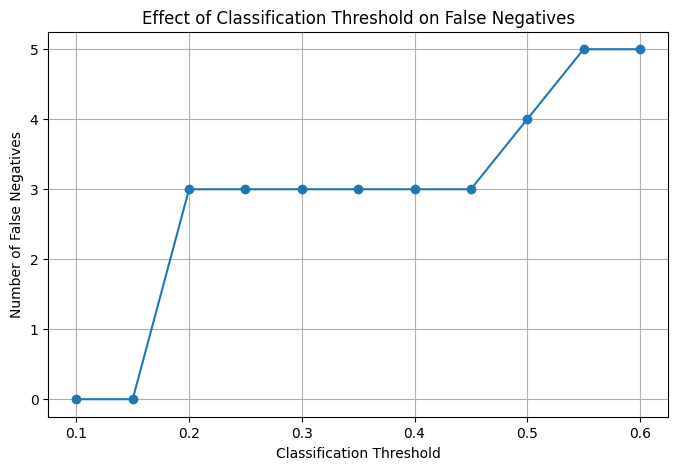

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["FN"],
    marker="o"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Number of False Negatives")
plt.title("Effect of Classification Threshold on False Negatives")

plt.grid(True)

plt.savefig("figures5/threshold_fn.png", dpi=600, bbox_inches="tight")
plt.show()

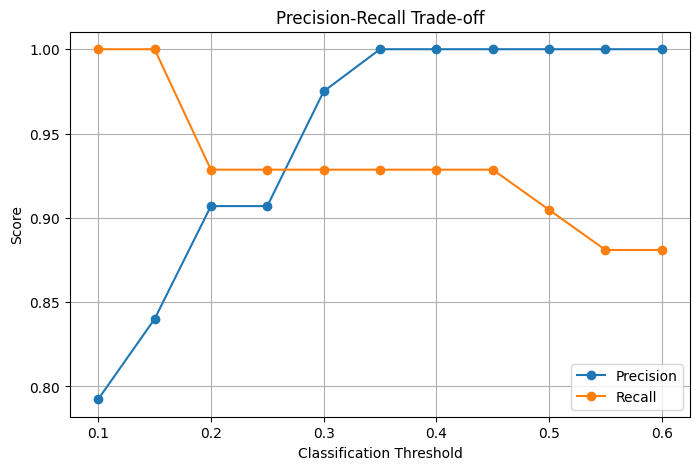

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off")

plt.legend()
plt.grid(True)

plt.savefig("figures5/precision_recall_tradeoff.png", dpi=600, bbox_inches="tight")
plt.show()

In [43]:
chosen_threshold = 0.35

y_pred_rf_threshold = (
    y_prob_rf >= chosen_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_rf_threshold
).ravel()

print("Threshold:", chosen_threshold)
print()
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

print()
print("Precision:", precision_score(y_test, y_pred_rf_threshold))
print("Recall   :", recall_score(y_test, y_pred_rf_threshold))
print("F1 Score :", f1_score(y_test, y_pred_rf_threshold))

Threshold: 0.35

True Negatives : 72
False Positives: 0
False Negatives: 3
True Positives  : 39

Precision: 1.0
Recall   : 0.9285714285714286
F1 Score : 0.9629629629629629


In [44]:
# Standard threshold
standard_threshold = 0.50

y_pred_standard = (
    y_prob_rf >= standard_threshold
).astype(int)

tn1, fp1, fn1, tp1 = confusion_matrix(
    y_test,
    y_pred_standard
).ravel()

# New threshold
y_pred_new = (
    y_prob_rf >= chosen_threshold
).astype(int)

tn2, fp2, fn2, tp2 = confusion_matrix(
    y_test,
    y_pred_new
).ravel()

comparison_threshold = pd.DataFrame({
    "Metric": [
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Threshold = 0.50": [
        tn1,
        fp1,
        fn1,
        tp1,
        precision_score(y_test, y_pred_standard),
        recall_score(y_test, y_pred_standard),
        f1_score(y_test, y_pred_standard)
    ],

    f"Threshold = {chosen_threshold:.2f}": [
        tn2,
        fp2,
        fn2,
        tp2,
        precision_score(y_test, y_pred_new),
        recall_score(y_test, y_pred_new),
        f1_score(y_test, y_pred_new)
    ]
})

display(comparison_threshold.round(3))

,Metric,Threshold = 0.50,Threshold = 0.35
0,True Negatives,72.000,72.000
1,False Positives,0.000,0.000
2,False Negatives,4.000,3.000
3,True Positives,38.000,39.000
4,Precision,1.000,1.000
5,Recall,0.905,0.929
6,F1 Score,0.950,0.963


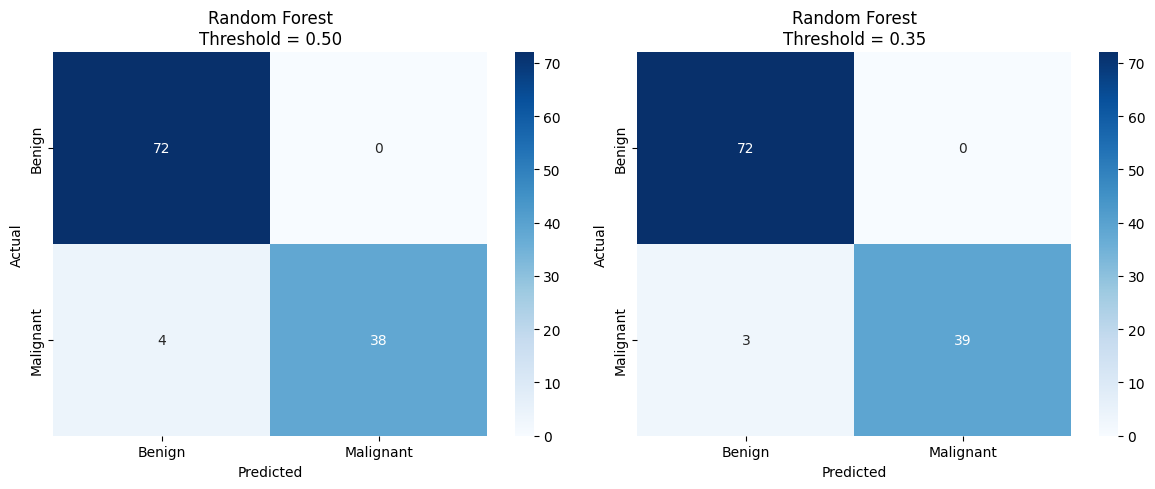

In [45]:
import seaborn as sns

cm_standard = confusion_matrix(
    y_test,
    y_pred_standard
)

cm_new = confusion_matrix(
    y_test,
    y_pred_new
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5)
)

# Standard threshold
sns.heatmap(
    cm_standard,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"],
    ax=axes[0]
)

axes[0].set_title("Random Forest\nThreshold = 0.50")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# New threshold
sns.heatmap(
    cm_new,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"],
    ax=axes[1]
)

axes[1].set_title(
    f"Random Forest\nThreshold = {chosen_threshold:.2f}"
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("figures5/threshold_confusion_matrices.png", dpi=600, bbox_inches="tight")
plt.show()

In [46]:
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]

dt_threshold_results = []

for threshold in thresholds:

    y_pred = (
        y_prob_dt >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    dt_threshold_results.append({
        "Threshold": threshold,
        "FN": fn,
        "FP": fp,
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        )
    })

dt_threshold_results = pd.DataFrame(
    dt_threshold_results
)

display(dt_threshold_results.round(3))

,Threshold,FN,FP,Precision,Recall,F1 Score
0,0.10,3,4,0.907,0.929,0.918
1,0.15,3,4,0.907,0.929,0.918
2,0.20,3,4,0.907,0.929,0.918
3,0.25,3,4,0.907,0.929,0.918
4,0.30,3,4,0.907,0.929,0.918
5,0.35,7,1,0.972,0.833,0.897
6,0.40,7,1,0.972,0.833,0.897
7,0.45,7,1,0.972,0.833,0.897
8,0.50,8,0,1.000,0.810,0.895
9,0.55,8,0,1.000,0.810,0.895


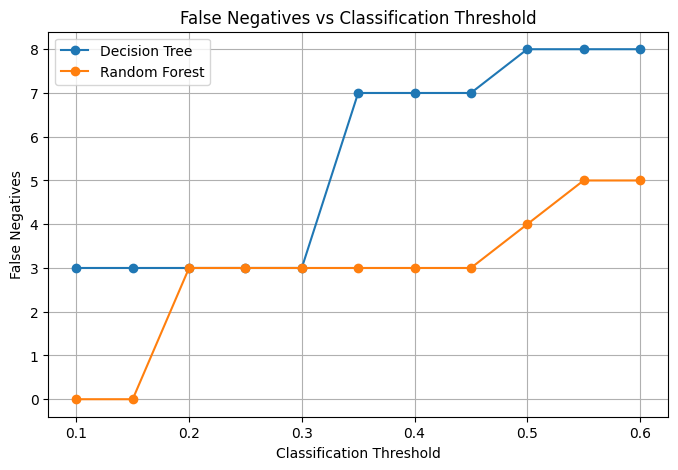

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(
    dt_threshold_results["Threshold"],
    dt_threshold_results["FN"],
    marker="o",
    label="Decision Tree"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["FN"],
    marker="o",
    label="Random Forest"
)

plt.xlabel("Classification Threshold")
plt.ylabel("False Negatives")
plt.title("False Negatives vs Classification Threshold")

plt.legend()
plt.grid(True)

plt.savefig("figures5/dt_rf_threshold_comparison.png", dpi=600, bbox_inches="tight")
plt.show()